# Yoga Dataset Downloader
Run all cells top to bottom. Takes ~3 minutes total.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Enter your Kaggle credentials

In [14]:
# ── EDIT THESE TWO LINES ONLY ─────────────────────────────────────────────
KAGGLE_USERNAME = 'fenilpatel05'   # ← paste your Kaggle username
KAGGLE_KEY      = '268114807d8a38dbcbe4cfc9241fa92a'    # ← paste your Kaggle API key
# ─────────────────────────────────────────────────────────────────────────

# How to get these:
# 1. Go to kaggle.com → click profile picture → Settings
# 2. Scroll to API section → click 'Create New Token'
# 3. Open downloaded kaggle.json → copy username and key values above

import os
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY
print('Credentials set!')

Credentials set!


## Cell 2 — Install Kaggle & download dataset

In [15]:
!pip install kaggle -q

import os
os.makedirs('/content/data/raw', exist_ok=True)

print('Downloading dataset...')
!kaggle datasets download -d shrutisaxena/yoga-pose-image-classification-dataset -p /content/data/raw
print('Download complete!')

Dataset URL: https://www.kaggle.com/datasets/shrutisaxena/yoga-pose-image-classification-dataset
License(s): copyright-authors
yoga-pose-image-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Download complete!


## Cell 3 — Unzip

In [16]:
import zipfile
from pathlib import Path

zip_path = '/content/data/raw/yoga-pose-image-classification-dataset.zip'

print('Extracting...')
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/data/raw/')
print('Extraction complete!')

print('\nExtracted folders:')
for f in sorted(Path('/content/data/raw').iterdir()):
    if f.is_dir():
        print(f'  {f.name}')

Extracting...
Extraction complete!

Extracted folders:
  dataset


## Cell 4 — Explore classes & image counts

In [17]:
from pathlib import Path

# Auto-find the folder that contains class subfolders
raw = Path('/content/data/raw')
SOURCE_DIR = None
for folder in raw.rglob('*/'):
    subdirs = [d for d in folder.iterdir() if d.is_dir()]
    if len(subdirs) >= 5:   # likely the class-level folder
        SOURCE_DIR = folder
        break

print(f'Source directory detected: {SOURCE_DIR}\n')
print(f'{"Class":<30} {"Images":>8}')
print('-' * 40)
total = 0
for cls in sorted(SOURCE_DIR.iterdir()):
    if not cls.is_dir(): continue
    n = len(list(cls.glob('*.jpg')) + list(cls.glob('*.png')) + list(cls.glob('*.jpeg')))
    print(f'{cls.name:<30} {n:>8}')
    total += n
print('-' * 40)
print(f'{"TOTAL":<30} {total:>8}')

Source directory detected: /content/data/raw/dataset

Class                            Images
----------------------------------------
adho mukha svanasana                 69
adho mukha vriksasana                59
agnistambhasana                      33
ananda balasana                      59
anantasana                           43
anjaneyasana                         64
ardha bhekasana                      40
ardha chandrasana                    52
ardha matsyendrasana                 90
ardha pincha mayurasana              47
ardha uttanasana                     66
ashtanga namaskara                   33
astavakrasana                        72
baddha konasana                      70
bakasana                             77
balasana                             71
bhairavasana                         46
bharadvajasana i                     54
bhekasana                            39
bhujangasana                         73
bhujapidasana                        61
bitilasana               

## Cell 5 — Pick your 8 poses

In [18]:
# ── EDIT: pick exactly 8 class names from the list printed above ──────────
SELECTED_CLASSES = [
    'adho mukha svanasana',
    'virabhadrasana i',
    'virabhadrasana ii',
    'vriksasana',
    'bhujangasana',
    'balasana',
    'dandasana',
    'chaturanga dandasana',
]
# ─────────────────────────────────────────────────────────────────────────

# Validate class names exist
available = [d.name for d in SOURCE_DIR.iterdir() if d.is_dir()]
for cls in SELECTED_CLASSES:
    status = 'OK' if cls in available else 'NOT FOUND — check spelling!'
    print(f'  {cls:<20} {status}')

  adho mukha svanasana OK
  virabhadrasana i     OK
  virabhadrasana ii    OK
  vriksasana           OK
  bhujangasana         OK
  balasana             OK
  dandasana            OK
  chaturanga dandasana OK


## Cell 6 — Train / val split (80% / 20%)

In [19]:
import shutil, random
from pathlib import Path

TARGET_DIR = Path('/content/data/yoga_poses')
SPLIT      = 0.80
SEED       = 42
random.seed(SEED)

print(f'Splitting into train ({int(SPLIT*100)}%) and val ({int((1-SPLIT)*100)}%)\n')
print(f'{"Class":<25} {"Train":>8} {"Val":>8} {"Total":>8}')
print('-' * 55)

for cls in SELECTED_CLASSES:
    cls_dir = SOURCE_DIR / cls
    images  = (list(cls_dir.glob('*.jpg')) +
               list(cls_dir.glob('*.jpeg')) +
               list(cls_dir.glob('*.png')))
    random.shuffle(images)
    cut        = int(len(images) * SPLIT)
    train_imgs = images[:cut]
    val_imgs   = images[cut:]

    (TARGET_DIR / 'train' / cls).mkdir(parents=True, exist_ok=True)
    (TARGET_DIR / 'val'   / cls).mkdir(parents=True, exist_ok=True)

    for img in train_imgs:
        shutil.copy(img, TARGET_DIR / 'train' / cls / img.name)
    for img in val_imgs:
        shutil.copy(img, TARGET_DIR / 'val'   / cls / img.name)

    print(f'{cls:<25} {len(train_imgs):>8} {len(val_imgs):>8} {len(images):>8}')

print('-' * 55)
print(f'\nDataset ready at: {TARGET_DIR}')

Splitting into train (80%) and val (19%)

Class                        Train      Val    Total
-------------------------------------------------------
adho mukha svanasana            55       14       69
virabhadrasana i                43       11       54
virabhadrasana ii               44       11       55
vriksasana                      49       13       62
bhujangasana                    58       15       73
balasana                        56       15       71
dandasana                       48       12       60
chaturanga dandasana            72       18       90
-------------------------------------------------------

Dataset ready at: /content/data/yoga_poses


## Cell 7 — Visualize one sample per class

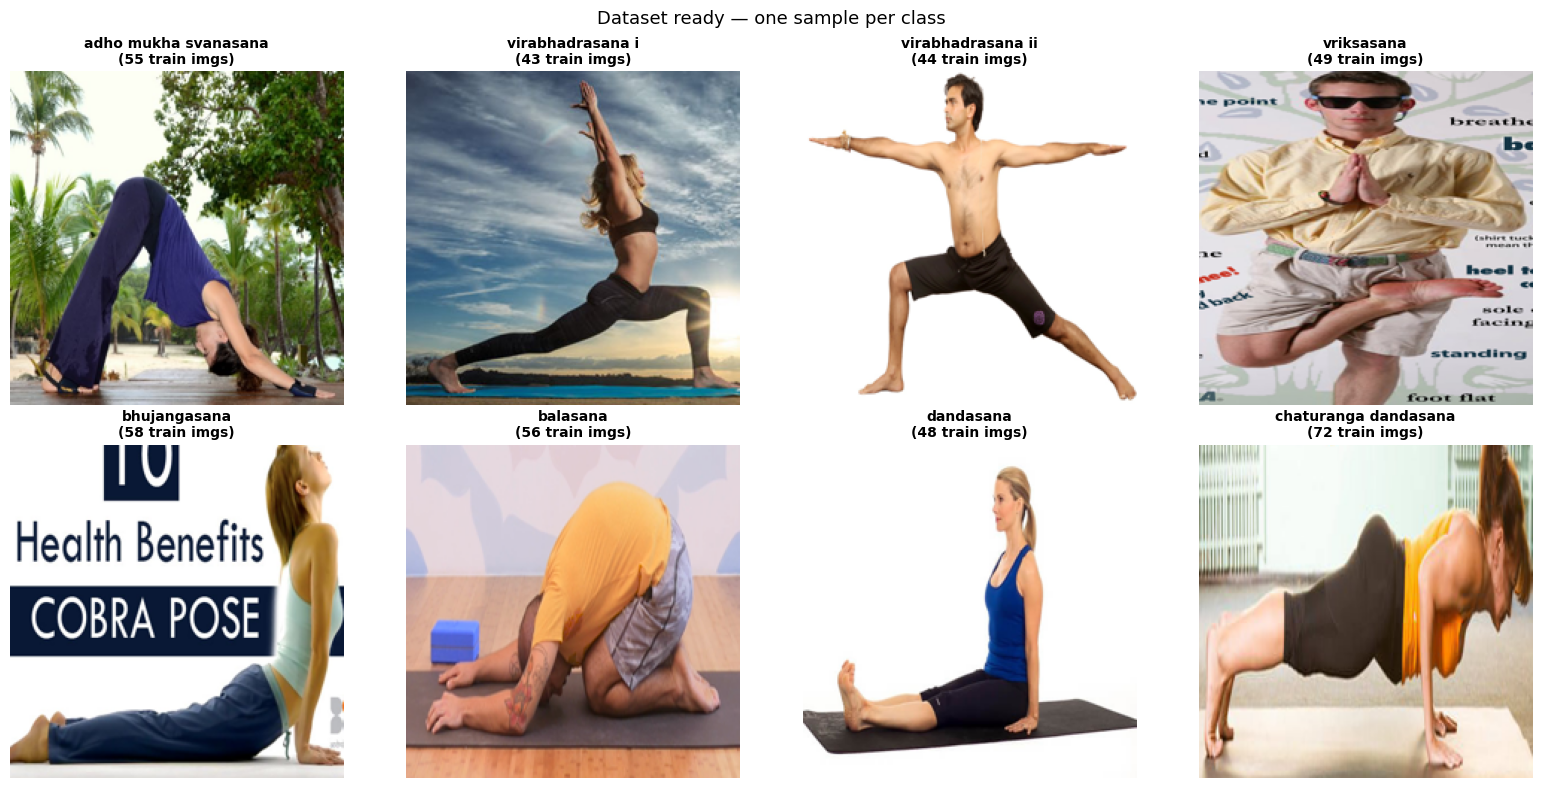


All done! Use this path in your training notebook:
  DATA_DIR = Path("/content/data/yoga_poses")


In [20]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

TARGET_DIR = Path('/content/data/yoga_poses')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flatten(), SELECTED_CLASSES):
    imgs = list((TARGET_DIR / 'train' / cls).glob('*.jpg')) + \
           list((TARGET_DIR / 'train' / cls).glob('*.png'))
    if imgs:
        img   = Image.open(imgs[0]).convert('RGB').resize((224, 224))
        count = len(list((TARGET_DIR / 'train' / cls).glob('*.*')))
        ax.imshow(img)
        ax.set_title(f'{cls}\n({count} train imgs)', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Dataset ready — one sample per class', fontsize=13)
plt.tight_layout()
plt.show()
print('\nAll done! Use this path in your training notebook:')
print('  DATA_DIR = Path("/content/data/yoga_poses")')

## Cell 8 — Save dataset to Google Drive (optional but recommended)

In [23]:
# Run this to save the dataset to Drive so you don't re-download next session
# from google.colab import drive
# drive.mount('/content/drive')

import shutil
shutil.copytree(
    '/content/data/yoga_poses',
    '/content/drive/MyDrive/Yoga-pose-detection ML project/',
    dirs_exist_ok=True
)
print('Saved to Google Drive!')

print('Uncomment the lines above if you want to save to Google Drive.')

Saved to Google Drive!
Uncomment the lines above if you want to save to Google Drive.
